In [24]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

from seqAE_model import SeqAutoencoder
from contra_seq_dataset import AnchoredSampler
from torch.utils.data import DataLoader, RandomSampler
from contra_seq_dataset import ContraSeqDataset, get_dataset_array, get_anc_map
from losses import SupConLoss, padce_loss
from tqdm.notebook import tqdm
import torch
import random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
TAG = '2022041219_01' 

use_losses = ['SupCon','Recon']
BS = 32
E = 50
NORMED_LATENT = True
use_cuda = True

# print(model_dir)

In [27]:
## Dataset
anc_path = 'model_dataset/anchor_smiles.csv'
aug_path = 'model_dataset/augmented_smiles_balanced.csv'

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)

In [28]:
import torch.nn as nn
import pandas as pd
import matplotlib.pylab as plt

# torch.cuda.empty_cache()
device =  torch.device("cuda" if use_cuda else "cpu")
model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

p = f'models/{TAG}/{E-1}.pt'
model.load_state_dict(torch.load(p), strict = False)

if use_cuda==True and torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model)
    model.to(device)
else:
    model = model.to(device)
    
model.eval()

Let's use 4 GPUs!


DataParallel(
  (module): SeqAutoencoder(
    (embedder): Embedding(31, 512)
    (pos_enc): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (enc): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=0.6, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=0.6, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
        (1): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuant

In [29]:
import seaborn as sns 
sns.set_theme(style='ticks',font_scale=1.25)
losses = pd.read_csv(f'training_logs/losses_{TAG}.csv',usecols=use_losses)

# figsize=(12.5,5)
# plt.figure(figsize=figsize)
# for label,data in losses.iteritems():
#     if label=='Recon':
#         plt.plot(data, label=label, color="peru")
#     elif label=='SupCon':
#         plt.plot(data, label=label, color="steelblue")
# plt.ylim(0,5)
# plt.title(f'Batch size: {BS}, Epochs: {E}')
# plt.grid(True)
# plt.xlabel('Run')
# plt.legend(loc='upper right')
# plt.savefig(f'training_logs/loss_plot_{TAG}.png', bbox_inches='tight')
# plt.show()

## UMAP a sample of training data.

In [30]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from matplotlib.offsetbox import OffsetImage,AnnotationBbox
import numpy as np
import copy

_df = copy.deepcopy(ds_arr)
_df.columns = ['Smiles','Atype','Label'] # [x[0].upper() + x[1:] for x in df.columns]

NUM_TO_EVAL = 500

random.seed(666)
rand = random.sample(range(0,10000),NUM_TO_EVAL)
rand_idc = np.concatenate([anc_map[x] for x in rand],axis=0)
print(rand_idc)

df = _df.iloc[rand_idc]
display(df)

from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype"]]

[ 7473 47365 47366 ... 36392 36393 36394]


,Smiles,Atype,Label
7473,N=C(NN=Cc1cccnc1)NN=Cc1cccnc1,Anc,7473
37365,Cc1cncc(C=NNC(=N)NN=Cc2cccnc2)c1,Aug,7473
37366,Cc1ccncc1C=NNC(=N)NN=Cc1cccnc1,Aug,7473
37367,Cc1ncccc1C=NNC(=N)NN=Cc1cccnc1,Aug,7473
37368,CC(=NNC(=N)NN=Cc1cccnc1)c1cccnc1,Aug,7473
...,...,...,...
26390,Cc1c(CNC2CCCC2)nc(O)[nH]c1=O,Aug,5278
26391,CC1(NCc2cc(=O)[nH]c(O)n2)CCCC1,Aug,5278
26392,CC1CCC(NCc2cc(=O)[nH]c(O)n2)C1,Aug,5278
26393,COc1nc(CNC2CCCC2)cc(=O)[nH]1,Aug,5278


### Get latent code from model.

In [31]:
normed = 'normed' if NORMED_LATENT else 'raw'
n_samp = NUM_TO_EVAL
tag_embedding = f'{TAG}_{normed}_{n_samp}anc'

print(tag_embedding)

2022041219_01_normed_500anc


In [32]:
from tqdm.notebook import trange, tqdm
loader = DataLoader(ds, batch_size=1, sampler=rand_idc, num_workers=0, pin_memory=True)

latents = []
for samp in tqdm(loader, total=len(df)):
    for k,v in samp.items():
        if torch.is_tensor(v):
            samp[k] = v.to(device)
    latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                              samp['avg_mask'], samp['out_mask'], NORMED_LATENT)
    latent = latent.cpu().detach().numpy()
    latents.append(latent)
    
latents = np.stack(latents,axis=0)
latents = latents.squeeze(1)
print(latents.shape)

  0%|          | 0/3000 [00:00<?, ?it/s]

(3000, 32)


In [33]:
import umap.umap_ as umap
umapper = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=2, metric='euclidean')
embedding = umapper.fit_transform(latents)

df['x'] = embedding[:, 0]
df['y'] = embedding[:, 1]

In [34]:
# coords = df[['x','y']]
# coords.to_csv(f'embeddings/coords_{tag_embedding}.csv')

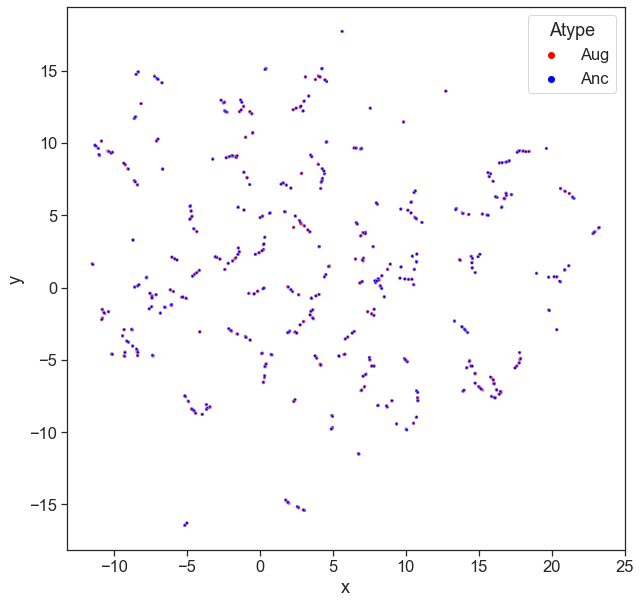

In [35]:
import seaborn as sns 
sns.set_theme(style='ticks',font_scale=1.5)

plt.figure(figsize=(10,10))

sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                alpha=0.5, s=10, palette={'Aug':'red'})
sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                alpha=1., s=7, palette={'Anc':'blue'})
# plt.savefig(f'embeddings/umap_{tag_embedding}.png', bbox_inches='tight')
plt.show()

In [36]:
%matplotlib inline
import plotly.graph_objs as go

from ipywidgets import Image, Layout, HBox, VBox
from rdkit.Chem import Draw
import PIL

import ipywidgets as widgets
import io

# Assemble all the traces.
trace_anchors = (go.Scattergl(x=df[df.Atype=='Anc']['x'], 
                           y=df[df.Atype=='Anc']['y'], 
                           name='Anchors',
                           marker=dict(size=3, opacity=0.75, color='blue'),
                           hoverinfo='text',
                           text=df[df.Atype=='Anc']['Smiles'],
                           mode='markers'))
trace_augmentations = (go.Scattergl(x=df[df.Atype=='Aug']['x'], 
                           y=df[df.Atype=='Aug']['y'], 
                           name='Augmentations',
                           marker=dict(size=3, opacity=0.75, color='red'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Atype=='Aug']['Smiles'],
                           mode='markers'))
data = [trace_augmentations, trace_anchors, ]

# Make figure.
fig = go.FigureWidget(data=data)
# fig.layout.hovermode = 'closest'
fig.update_layout(template='simple_white', autosize=False, height=512)
fig.update_yaxes(scaleanchor = "x", scaleratio = 1.)

# Show-mol-on-hover function.
img = open('white.png','rb').read()
# img = PIL.Image.new('1', (256, 256)).tobytes()
image_widget = Image(value=img)

def hover_fn(trace, points, state):
    
    if points.point_inds:
        if trace['name']=='Anchors':
            my_df = df[df.Atype=='Anc']
        elif trace['name']=='Augmentations':
            my_df = df[df.Atype=='Aug']
            
        idx = points.point_inds[0]
        datum = my_df.iloc[idx]
        mol = datum.Mol

        img = Draw.MolToImage(mol,size=(256, 512))  ### to make mol image smaller, alter first dim. 
        imgByteArr = io.BytesIO()
        img.save(imgByteArr, format='PNG')
        imgByteArr = imgByteArr.getvalue()
        image_widget.value = imgByteArr

for trace_num in range(len(fig.data)):
    fig.data[trace_num].on_hover(hover_fn)  
HBox([HBox([image_widget]),fig])